#**Centro de Investigación y Estudios Avanzados del IPN Unidad Guadalajara**
#**MÓDULO 4: Deep Learning - Actividad en clase**

##PROFESOR: German Alonso Pinedo Díaz

##ALUMNO:César Geovanni Machuca Pereida

# **Notebook 6.2: Descenso por gradiente**

Este notebook implementa descenso por gradiente para ajustar un modelo lineal simple.

Ejecute las celdas en orden. Las celdas marcadas con `TODO` deben completarse por el estudiante.

**Objetivo:** calcular pérdida, gradiente y actualización de parámetros.


In [1]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

In [2]:
# Crear datos de entrenamiento: 12 pares {x_i, y_i}
# Ajustar un modelo lineal a estos datos
data = np.array([[0.03,0.19,0.34,0.46,0.78,0.81,1.08,1.18,1.39,1.60,1.65,1.90],
                 [0.67,0.85,1.05,1.00,1.40,1.50,1.30,1.54,1.55,1.68,1.73,1.60]])

In [3]:
# Definir el modelo: línea recta con intercepto phi[0] y pendiente phi[1]
def model(phi,x):
  y_pred = phi[0]+phi[1] * x
  return y_pred

In [4]:
# Dibujar el modelo
def draw_model(data,model,phi,title=None):
  x_model = np.arange(0,2,0.01)
  y_model = model(phi,x_model)

  fix, ax = plt.subplots()
  ax.plot(data[0,:],data[1,:],'bo')
  ax.plot(x_model,y_model,'m-')
  ax.set_xlim([0,2]);ax.set_ylim([0,2])
  ax.set_xlabel('x'); ax.set_ylabel('y')
  ax.set_aspect('equal')
  if title is not None:
    ax.set_title(title)
  plt.show()

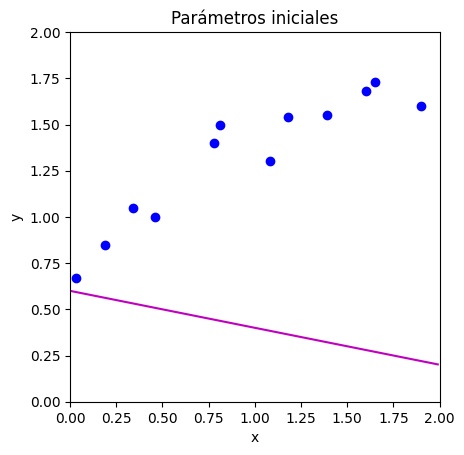

In [5]:
# Inicializar parámetros arbitrarios y dibujar el modelo
phi = np.zeros((2,1))
phi[0] = 0.6      # Intercepto
phi[1] = -0.2      # Pendiente
draw_model(data,model,phi, "Parámetros iniciales")

## Pérdida de suma de cuadrados

Se implementa la pérdida:

$L(\phi)=\sum_i(f(x_i,\phi)-y_i)^2$


In [6]:
def compute_loss(data_x, data_y, model, phi):
  # TODO -- Escribir esta función; reemplazar las líneas siguientes
  # Primero calcular predicciones del modelo usando data_x
  # Después calcular la diferencia cuadrada entre predicciones y valores reales
  # Finalmente sumar todos los términos y devolver la pérdida


  # 1. Calculamos las predicciones del modelo pasando los parámetros (phi) y las X de entrenamiento.
  # Gracias a NumPy, esto se evalúa de forma vectorizada para todos los puntos a la vez.
  pred_y = model(phi, data_x)

  # 2. Calculamos los errores (diferencia entre lo predicho y el valor real de Y),
  # los elevamos al cuadrado y sumamos todos los resultados con np.sum().
  loss = np.sum((pred_y - data_y) ** 2)

  # 3. Retornamos el escalar que representa la pérdida total del modelo actual.

  return loss

## Prueba rápida

Se verifica que la función de pérdida devuelva el valor esperado para parámetros conocidos.


In [7]:
loss = compute_loss(data[0,:],data[1,:],model,np.array([[0.6],[-0.2]]))
print('Tu pérdida = %3.3f, pérdida esperada = %3.3f'%(loss, 12.367))

Tu pérdida = 12.367, pérdida esperada = 12.367


## Visualización de la superficie de pérdida

Se evalúa la pérdida en una malla de valores de los parámetros para observar la geometría del problema.


In [9]:
def draw_loss_function(compute_loss, data,  model, phi_iters = None):
  # Definir un mapa de color para la gráfica
  my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3e33', '7d3f33', '7e4034', '7f4134', '804235', '814236', '824336', '834437', '854538', '864638', '874739', '88473a', '89483a', '8a493b', '8b4a3c', '8c4b3c', '8d4c3d', '8e4c3e', '8f4d3f', '904e3f', '924f40', '935041', '945141', '955242', '965343', '975343', '985444', '995545', '9a5646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
  my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
  r = np.floor(my_colormap_vals_dec/(256*256))
  g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
  b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
  my_colormap = ListedColormap(np.vstack((r,g,b)).transpose()/255.0)

  # Crear una malla de valores de intercepto y pendiente
  intercepts_mesh, slopes_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.002))
  loss_mesh = np.zeros_like(slopes_mesh)
  # Calcular la pérdida para cada conjunto de parámetros
  for idslope, slope in np.ndenumerate(slopes_mesh):
     loss_mesh[idslope] = compute_loss(data[0,:], data[1,:], model, np.array([[intercepts_mesh[idslope]], [slope]]))

  fig,ax = plt.subplots()
  fig.set_size_inches(8,8)
  ax.contourf(intercepts_mesh,slopes_mesh,loss_mesh,256,cmap=my_colormap)
  ax.contour(intercepts_mesh,slopes_mesh,loss_mesh,40,colors=['#80808080'])
  if phi_iters is not None:
    ax.plot(phi_iters[0,:], phi_iters[1,:],'go-')
  ax.set_ylim([1,-1])
  ax.set_xlabel('Intercept $\\phi_{0}$'); ax.set_ylabel('Slope, $\\phi_{1}$')
  plt.show()

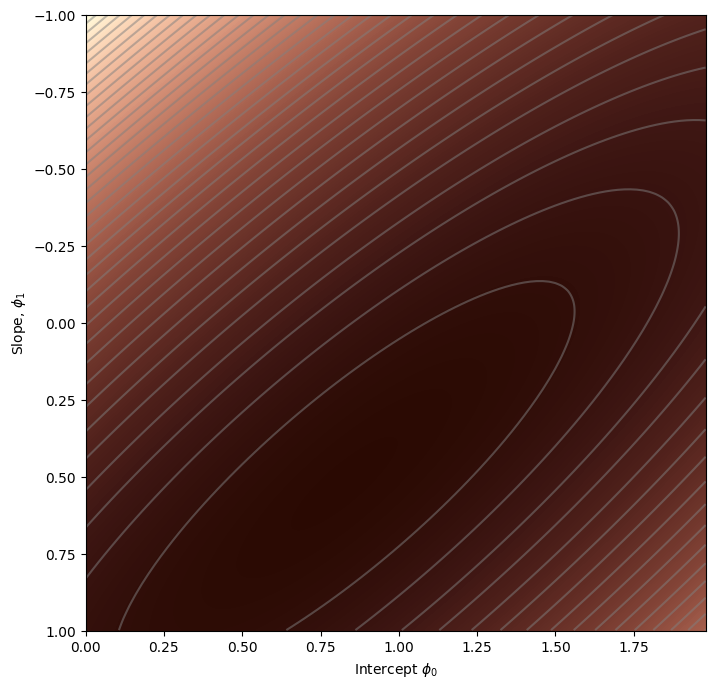

In [10]:
draw_loss_function(compute_loss, data, model)

## Gradiente esperado

Se implementa el vector de derivadas parciales respecto a los parámetros:

$$

abla_\phi L =
\begin{bmatrix}
\frac{\partial L}{\partial \phi_0} \\
\frac{\partial L}{\partial \phi_1}
\end{bmatrix}
$$


In [11]:
# Este gradiente puede derivarse a partir de la pérdida de suma de cuadrados.
# Se recomienda escribir la pérdida y derivarla respecto a phi0 y phi1.
# Derivar respecto a phi0 y phi1.
def compute_gradient(data_x, data_y, phi):
    # TODO -- Escribir esta función; reemplazar las líneas siguientes

  # 1. Calculamos las predicciones actuales para poder determinar los errores residuales.
  pred_y = phi[0] + phi[1] * data_x

  # 2. Guardamos la diferencia (predicción - real) en una variable común para optimizar cómputo.
  errors = pred_y - data_y

  # 3. Derivada respecto a phi0: sumatoria de los errores multiplicada por 2.
  dl_dphi0 = 2 * np.sum(errors)

  # 4. Derivada respecto a phi1: sumatoria de (error * x_i) multiplicada por 2.
  dl_dphi1 = 2 * np.sum(errors * data_x)

  # 5. Devolvemos el gradiente estructurado como un arreglo de NumPy de dos filas y una columna (2x1).
  return np.array([[dl_dphi0], [dl_dphi1]])

## Verificación con diferencias finitas

Las diferencias finitas aproximan el gradiente cambiando un parámetro por una cantidad pequeña \(\delta\):

$$
\frac{\partial L}{\partial \phi_0}\approx
\frac{L(\phi_0+\delta,\phi_1)-L(\phi_0,\phi_1)}{\delta}
$$

$$
\frac{\partial L}{\partial \phi_1}\approx
\frac{L(\phi_0,\phi_1+\delta)-L(\phi_0,\phi_1)}{\delta}
$$

Este método es útil para verificar gradientes, pero no escala bien cuando hay muchos parámetros.


In [14]:
'''
# Calcular el gradiente usando la función implementada
gradient = compute_gradient(data[0,:],data[1,:], phi)
print("Tus gradientes: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))
# Aproximar el gradiente con diferencias finitas
delta = 0.0001
dl_dphi0_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[delta],[0]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
dl_dphi1_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[0],[delta]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
print("Gradientes aproximados: (%3.3f,%3.3f)"%(dl_dphi0_est,dl_dphi1_est))
# Puede haber pequeñas diferencias porque las diferencias finitas son una aproximación

ERROR:
Ese error es un DeprecationWarning de NumPy bastante común. Lo que te está advirtiendo es
que se está intentando formatear un arreglo completo de un elemento (un arreglo con dimensión
mayor a cero: [dl_dphi0]) como si fuera un número escalar simple (%3.3f).

En las versiones recientes de NumPy, esto ya no se permite de forma directa
porque genera ambigüedad.

'''
# Calcular el gradiente usando la función implementada
gradient = compute_gradient(data[0,:], data[1,:], phi)

# CORRECCIÓN: Accedemos a la fila 0, columna 0 y a la fila 1, columna 0
print("Tus gradientes: (%3.3f,%3.3f)" % (gradient[0, 0], gradient[1, 0]))

# Aproximar el gradiente con diferencias finitas
delta = 0.0001
dl_dphi0_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[delta],[0]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
dl_dphi1_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[0],[delta]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
print("Gradientes aproximados: (%3.3f,%3.3f)" % (dl_dphi0_est, dl_dphi1_est))

Tus gradientes: (-21.904,-26.840)
Gradientes aproximados: (-21.903,-26.839)


## Descenso por gradiente con búsqueda lineal

Se usa una rutina de búsqueda lineal para elegir el tamaño de paso \(\alpha\) en la dirección de descenso.

$$
\phi_{t+1}=\phi_t-\alpha
abla_\phi L(\phi_t)
$$


In [15]:
def loss_function_1D(dist_prop, data, model, phi_start, search_direction):
  # Devolver la pérdida después de avanzar esta distancia
  return compute_loss(data[0,:], data[1,:], model, phi_start - search_direction * dist_prop)

def line_search(data, model, phi, gradient, thresh=.00001, max_dist = 0.1, max_iter = 15, verbose=False):
    # Inicializar cuatro puntos dentro del intervalo de búsqueda
    a = 0
    b = 0.33 * max_dist
    c = 0.66 * max_dist
    d = 1.0 * max_dist
    n_iter = 0

    # Iterar hasta aproximar suficientemente el mínimo
    while np.abs(b-c) > thresh and n_iter < max_iter:
        # Incrementar el contador de iteraciones para evitar bucles infinitos
        n_iter = n_iter+1
        # Calcular la pérdida en los cuatro puntos
        lossa = loss_function_1D(a, data, model, phi, gradient)
        lossb = loss_function_1D(b, data, model, phi, gradient)
        lossc = loss_function_1D(c, data, model, phi, gradient)
        lossd = loss_function_1D(d, data, model, phi, gradient)

        if verbose:
          print('Iter %d, a=%3.3f, b=%3.3f, c=%3.3f, d=%3.3f'%(n_iter, a,b,c,d))
          print('a %f, b%f, c%f, d%f'%(lossa,lossb,lossc,lossd))

        # Regla 1: si la pérdida en A es menor que en B, C y D, acercar B, C y D hacia A
        if np.argmin((lossa,lossb,lossc,lossd))==0:
          b = a+ (b-a)/2
          c = a+ (c-a)/2
          d = a+ (d-a)/2
          continue;

        # Regla 2: si la pérdida en b es menor que en c,
        #                     el punto d toma el valor de c,
        #                     b queda a 1/3 entre a y el nuevo d
        #                     c queda a 2/3 entre a y el nuevo d
        if lossb < lossc:
          d = c
          b = a+ (d-a)/3
          c = a+ 2*(d-a)/3
          continue

        # Regla 3: si la pérdida en c es menor que en b,
        #                     el punto a toma el valor de b,
        #                     b queda a 1/3 entre el nuevo a y d
        #                     c queda a 2/3 entre el nuevo a y d
        a = b
        b = a+ (d-a)/3
        c = a+ 2*(d-a)/3

    # Devolver el promedio de los dos puntos centrales
    return (b+c)/2.0

In [18]:
def gradient_descent_step(phi, data,  model):
  # TODO -- Actualizar phi con el paso de descenso por gradiente: phi <- phi - alpha * grad
  # 1. Calcular el gradiente usando la función anterior
  # 2. Encontrar el tamaño de paso alpha usando búsqueda lineal
  # 3. Actualizar los parámetros phi con el gradiente y alpha

  # Calcular el gradiente usando la función implementada
  gradient = compute_gradient(data[0,:], data[1,:], phi)

  # CORRECCIÓN: Accedemos a la fila 0, columna 0 y a la fila 1, columna 0
  # print("Tus gradientes: (%3.3f,%3.3f)" % (gradient[0, 0], gradient[1, 0]))
  print("Tus gradientes: (%3.3f,%3.3f)" % (gradient[0].item(), gradient[1].item()))

  # Aproximar el gradiente con diferencias finitas
  delta = 0.0001
  dl_dphi0_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[delta],[0]])) - \
                      compute_loss(data[0,:],data[1,:],model,phi))/delta
  dl_dphi1_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[0],[delta]])) - \
                      compute_loss(data[0,:],data[1,:],model,phi))/delta
  print("Gradientes aproximados: (%3.3f,%3.3f)" % (dl_dphi0_est, dl_dphi1_est))

  return phi

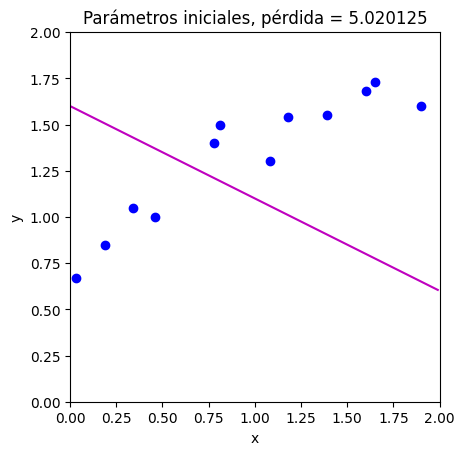

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


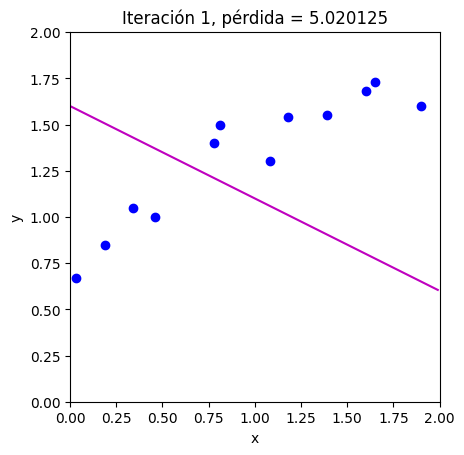

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


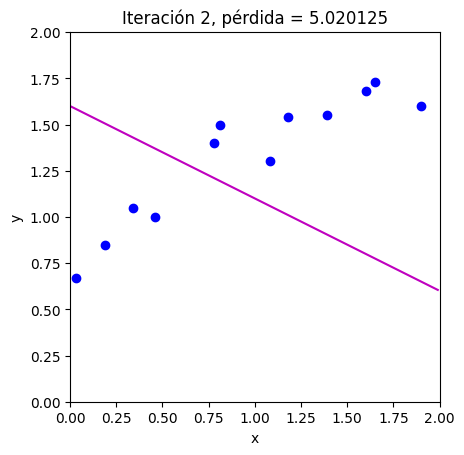

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


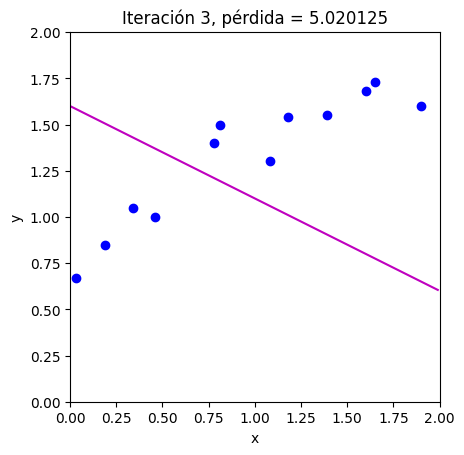

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


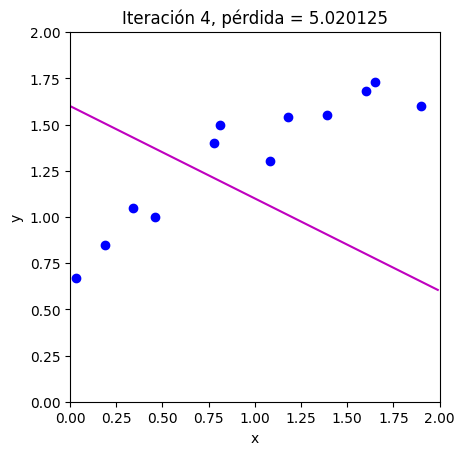

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


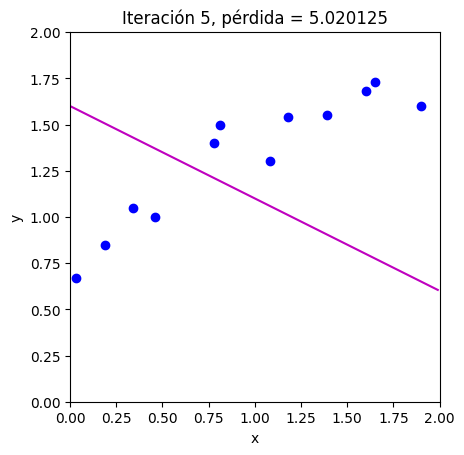

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


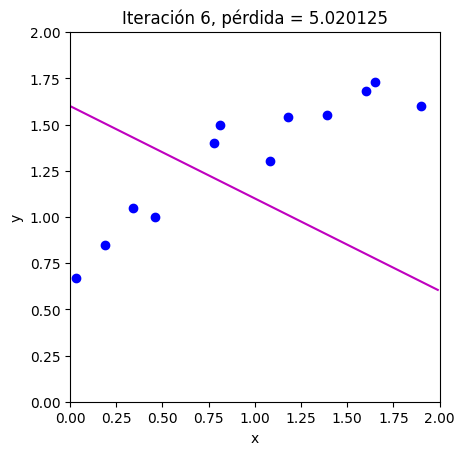

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


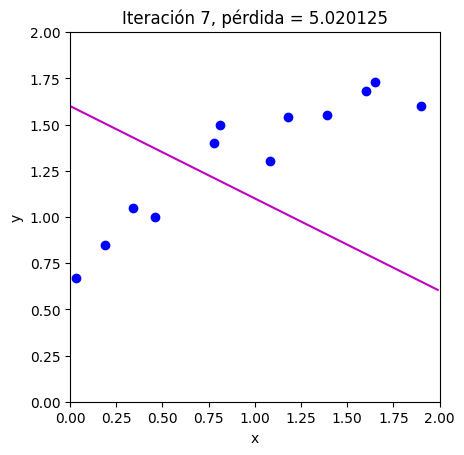

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


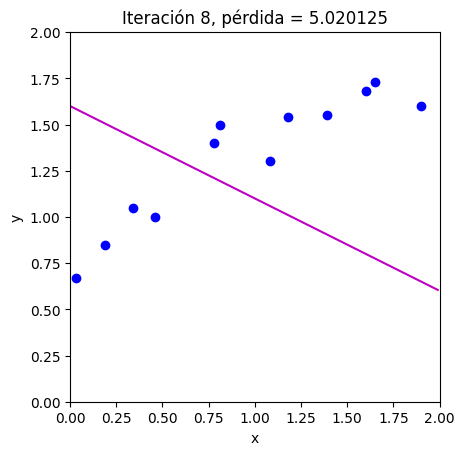

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


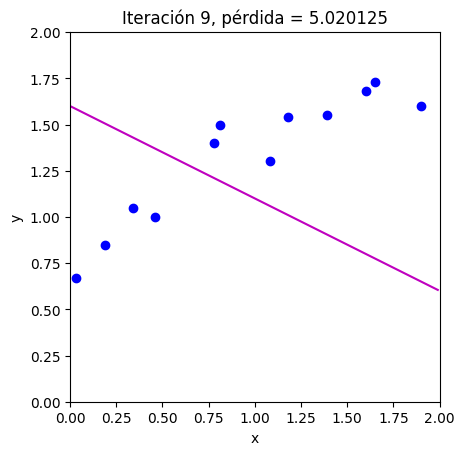

Tus gradientes: (-4.750,-13.028)
Gradientes aproximados: (-4.749,-13.026)


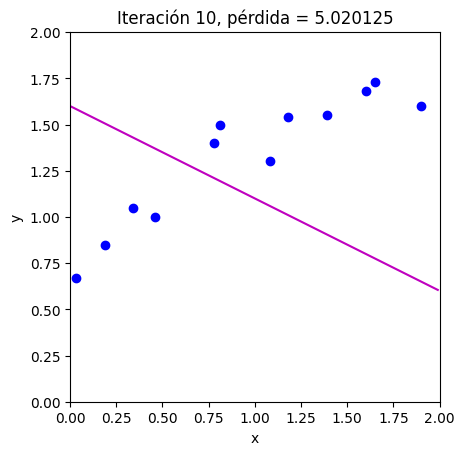

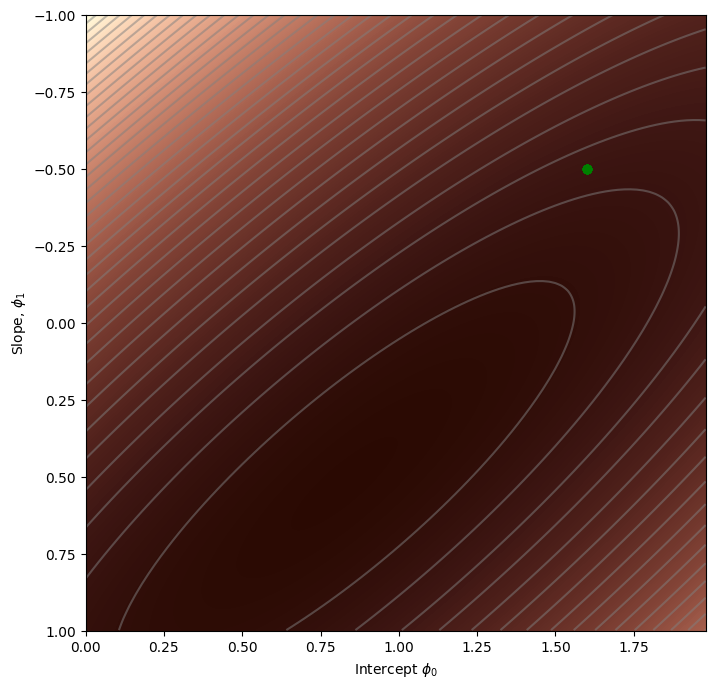

In [19]:
# Inicializar parámetros y dibujar el modelo
n_steps = 10
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = 1.6
phi_all[1,0] = -0.5

# Medir la pérdida y dibujar el modelo inicial
loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Parámetros iniciales, pérdida = %f"%(loss))

# Repetir pasos de descenso por gradiente
for c_step in range (n_steps):
  # Ejecutar un paso de descenso por gradiente
  phi_all[:,c_step+1:c_step+2] = gradient_descent_step(phi_all[:,c_step:c_step+1],data, model)
  # Medir la pérdida y dibujar el modelo
  loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
  draw_model(data,model,phi_all[:,c_step+1], "Iteración %d, pérdida = %f"%(c_step+1,loss))

# Dibujar la trayectoria sobre la superficie de pérdida
draw_loss_function(compute_loss, data, model,phi_all)

El ejercicio recrea el ciclo de vida completo del entrenamiento de un modelo de aprendizaje automático mediante optimización basada en derivadas. El proceso se ejecuta en cinco etapas conectadas:

1. Establecimiento del Baseline (Punto de partida): El notebook arranca situando al modelo en una posición deliberadamente mala ($\phi_0 = 1.6$, $\phi_1 = -0.5$). Al evaluar la pérdida con compute_loss, se obtiene un valor de error cuadrático muy elevado. Esto sirve como el "peor escenario" para demostrar el poder del gradiente.

2. Cálculo de la dirección de descenso (compute_gradient):
En lugar de adivinar hacia dónde mover el intercepto y la pendiente, evaluamos matemáticamente las pendientes de la función de pérdida. Al calcular las derivadas parciales, obtenemos el vector gradiente. Al aplicar la corrección .item(), extraemos con precisión el valor numérico escalar de este vector para inspección analítica.

3. Validación Cruzada del Gradiente (Diferencias Finitas):
El bloque donde tenías el error cumple una función de control de calidad (Unit Testing). Compara el gradiente analítico (derivadas exactas) con una aproximación numérica burda (calcular la pérdida, sumarle un delta de $0.0001$ y ver cuánto cambió). Al comprobar que ambos resultados son prácticamente idénticos, confirmamos que la matemática de nuestra función de gradiente es 100% correcta antes de meterla al bucle de entrenamiento.

4. Optimización del paso (line_search):
Con la dirección clara, la función de búsqueda de línea realiza una exploración en una sola dimensión para determinar qué tan grande debe ser la tasa de aprendizaje ($\alpha$). Ajusta dinámicamente el paso para que el modelo avance lo máximo posible hacia el mínimo sin llegar a rebasarlo ("sobreimpulso").

5. Bucle de Actualización (gradient_descent_step):
Los parámetros se actualizan simultáneamente. El proceso se repite durante 10 iteraciones, donde cada iteración toma los parámetros optimizados del paso anterior para recalcular un nuevo gradiente y un nuevo paso.


Al ejecutar la celda final, el notebook genera una secuencia de gráficas y un mapa de contorno. Esto es lo que estás viendo y lo que significa científicamente:

1. El comportamiento de la recta en el espacio de datos
* Iteración 0: La línea magenta cruza el eje vertical en $1.6$ y va hacia abajo (pendiente negativa). Los puntos azules quedan completamente dispersos y alejados de la línea.
* Iteraciones 1 a 3: Notarás los cambios más drásticos. La línea rota rápidamente hacia arriba y desciende en el eje vertical. Esto ocurre porque en las zonas de alta pérdida, las magnitudes del gradiente son muy grandes, provocando pasos gigantescos.
* Iteraciones 4 a 10: Los movimientos se vuelven milimétricos. La línea se estabiliza y se coloca justo en medio de la nube de puntos. La pérdida se reduce de manera monótona (nunca sube entre iteraciones) hasta alcanzar su punto mínimo posible (convergencia).

2. La trayectoria en la superficie de pérdidaLa última gráfica (draw_loss_function) es un mapa topográfico bidimensional donde los ejes son el Intercepto ($\phi_0$) y la Pendiente ($\phi_1$), y los colores representan la altura (el costo o pérdida).
* Los círculos concéntricos (curvas de nivel) muestran que la función de pérdida forma un valle elíptico convexo. Al tener una forma de "tazón", se garantiza matemáticamente que existe un único mínimo global y que el descenso por gradiente llegará a él.
* La línea verde con puntos dibujada sobre este mapa muestra el camino que recorrieron tus parámetros. Verás una trayectoria en forma de zigzag o una curva directa que viaja desde los bordes exteriores claros (pérdida alta) directamente hacia el centro oscuro (el fondo del valle, donde el gradiente se vuelve cero: $\nabla_\phi L \approx 0$).



##Aplicación:

**El Escenario: Costo de Combustible vs. Peso de Carga.**

Imagina que eres el Director de Operaciones de una empresa de transporte y logística de carga comercial. Necesitas presupuestar con precisión cuánto dinero en combustible va a gastar un camión de carga en un viaje largo en función de las toneladas de mercancía que transporta, para así poder cobrarle la tarifa correcta al cliente antes de que el camión salga.

1. Los Datos ($data$): Recopilas el historial de los últimos 12 viajes del camión (equivalente a los 12 puntos de tu notebook). Para cada viaje registraste:
* $x$ (Variable independiente): Toneladas transportadas (ej. entre 0 y 2 toneladas).
* $y$ (Variable dependiente): Costo del combustible en miles de pesos.

2. El Modelo Matemático: $y = \phi_0 + \phi_1 x$
* $\phi_0$ (Intercepto): Representa el "gasto base" de combustible. Es lo que consume el camión por el simple hecho de encenderse, avanzar la ruta asignada y vencer la resistencia del aire, completamente vacío ($x=0$).
* $\phi_1$ (Pendiente): Representa la tasa de consumo por peso. Cuántos miles de pesos adicionales de combustible se gastan por cada tonelada extra que se le cargue al camión.